# 🍼 Class 05 — Child Nutrition Survey Dataset: Label Encoding

## 📌 ভূমিকা (Introduction)

এই নোটবুকে আমরা একটি **Child Nutrition Survey Dataset** নিয়ে কাজ করব। এটি একটি Real-world Survey Data — যেখানে মানুষের কাছ থেকে শিশুর পুষ্টি সম্পর্কিত বিভিন্ন প্রশ্নের উত্তর সংগ্রহ করা হয়েছে।

### আমাদের লক্ষ্য (Our Task):
- Dataset লোড ও Explore করা
- অপ্রয়োজনীয় Column (`Timestamp`, `Name`) মুছে ফেলা
- **Label Encoding** দিয়ে সব Categorical (Text) Column কে Numerical এ রূপান্তর করা — যাতে ML Model বুঝতে পারে

---

### 🧠 Label Encoding কী এবং কেন?

ML Model শুধু **সংখ্যা (Number)** বোঝে — Text বোঝে না। কিন্তু Survey Data-তে উত্তর থাকে Text আকারে, যেমন:
- "Male" / "Female"
- "Yes" / "No"
- "Agree" / "Disagree" / "Neutral"

**Label Encoding** এই Text উত্তরগুলোকে সংখ্যায় রূপান্তর করে:

| Text | Encoded Number |
|---|---|
| Female | 0 |
| Male | 1 |
| Yes | 1 |
| No | 0 |

> 💡 Label Encoder প্রতিটি Unique মানকে **Alphabetical Order** অনুযায়ী 0, 1, 2, 3... সংখ্যা দেয়।

---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 📂 Dataset লোড করা

Survey থেকে সংগৃহীত CSV ফাইল লোড করা হচ্ছে। এই Dataset-এ প্রতিটি Row একজন Respondent-এর উত্তর এবং প্রতিটি Column একটি প্রশ্ন।

> ⚠️ **সাধারণ ভুল:** Colab-এ `/content/` path সঠিক, কিন্তু ফাইল আগে আপলোড না করলে `FileNotFoundError` আসবে।

In [2]:
dataset=pd.read_csv('/content/data.csv')

## 👀 সম্পূর্ণ Dataset দেখা

Dataset-এর সব Row ও Column দেখা হচ্ছে — এতে ডেটার প্রকৃতি ও পরিসর সম্পর্কে প্রাথমিক ধারণা তৈরি হবে।

In [3]:
dataset

,Timestamp,What is your name?,What is your age?,What is your gender?,A child should sleep?,"At what ages do food allergies, iron deficiency and occur in children?",During the early growing stage of a child the cause of malnutrition according to you is-,Child nutrition can also effect by,During puberty most of the child need to take proper amount of nutrients because,The most important nutrition source of an infant or baby is breast feeding. Without breast feeding they can be grownup but do you think it can be,A girl child needs to have best care during puberty,The most common malnutrition of children in our country,Do you prefer parental awareness in case of a sound health of a child,Nutrition of a child related to,Diarrhea is a very common disease of infant. According to you it happens due to,Some people think that feeding a child more and more Can increase their body growth. But according to you it is a,"Whole grain foods such as breads, cereals that are high in Fibre",Toddlers & preschoolers should have following nutrients in their diet
0,12/24/2022 15:02:36,Ayesha Siraji Shejuty,21,Female,8 to 9 hrs,3 to 6 year,Poverty,Quantity of intake food,They have started to growing,Malnutrition,Due to her mental health,Rickets,Strongly agree,Quantity of nutrients,Lack of cleanliness to the instruments that ar...,Cause of malnutrition,Making stool,Milk for the growth but sometimes it causes mi...
1,12/24/2022 15:08:21,Nushrah Ipshita,18,Female,8 to 9 hrs,3 to 6 year,Poverty,Environment,They have started to growing,Malnutrition,Due to her mental health,Marasmus,Strongly agree,Quantity of nutrients,Unhealthy environment,Cause of malnutrition,Making stool,Milk for the growth but sometimes it causes mi...
2,12/24/2022 15:09:34,Nabhan Ezaz Ilhan,18,Male,8 to 9 hrs,3 to 6 year,Lack of parental awareness,Family care,The growth rate is massive in this period,No if proper nutrients is getting by other foo...,Attractions towards uncertainty,Marasmus,Strongly agree,"Including vegetables, fruits",Lack of cleanliness to the instruments that ar...,Cause of malnutrition,Making stool,Milk for the growth but sometimes it causes mi...
3,12/24/2022 17:38:50,Rashedul Hoque Robin,23,Male,8 to 9 hrs,3 to 6 year,Lack of parental awareness,Environment,They have started to growing,No if proper nutrients is getting by other foo...,Due to her mental health,Rickets,Agree,"Including vegetables, fruits",Unhealthy environment,Overweight,Helps bone growth,Calcium for bone growth
4,12/24/2022 17:50:51,Mubashira Hoque,22,Female,9 to 10 hrs,3 to 6 year,Poverty,Family care,They have started to growing,Malnutrition,Physiological change,Rickets,Agree,Quantity of nutrients,Lack of cleanliness to the instruments that ar...,Overweight,Making stool,Calcium for bone growth
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,1/1/2023 22:10:57,Nila rahman,19,Female,8 to 9 hrs,3 to 6 year,Poverty,Physical well-being,They have started to growing,Malnutrition,Due to her mental health,Rickets,Strongly agree,Quantity of nutrients,Unhealthy environment,Cause of malnutrition,Helps bone growth,Calcium for bone growth
407,1/1/2023 22:11:29,Abayat Rahman,21,Male,8 to 9 hrs,1 to 3 year,Poverty,Family care,They have started to growing,No if proper nutrients is getting by other foo...,Attractions towards uncertainty,Rickets,Strongly agree,Quantity of nutrients,Lack of cleanliness to the instruments that ar...,Overweight,Helps bone growth,Calcium for bone growth
408,1/1/2023 22:12:13,Talha Ahmed,23,Male,8 to 9 hrs,1 to 3 year,Lack of parental awareness,Environment,They have started to growing,Malnutrition,Due to her mental health,Rickets,Strongly agree,Quantity of nutrients,Lack of cleanliness to the instruments that ar...,Cause of malnutrition,Making stool,Calcium for bone growth
409,1/1/2023 22:12:49,Latifur Rahman,21,Male,8 to 9 hrs,1 to 3 year,Lack of parental awareness,Environment,They have started to growing,No if proper nutrients is getting by other foo...,A

## ❓ Null Value চেক করা

**To check Null Value** ✅

Survey Data-তে প্রায়ই কিছু মানুষ কিছু প্রশ্নের উত্তর না দিয়ে বাদ দিয়ে যায় — ফলে Null Value তৈরি হয়। ML Model-এ দেওয়ার আগে এগুলো Handle করতে হয়।

> 💡 যদি কোনো Column-এ Null থাকে, পরবর্তীতে `fillna()` বা `dropna()` দিয়ে সেটা Handle করতে হবে।

In [4]:
dataset.isnull().sum()

,0
Timestamp,0
What is your name?,0
What is your age?,0
What is your gender?,0
A child should sleep?,0
"At what ages do food allergies, iron deficiency and occur in children?",0
During the early growing stage of a child the cause of malnutrition according to you is-,0
Child nutrition can also effect by,0
During puberty most of the child need to take proper amount of nutrients because,0
The most important nutrition source of an infant or baby is breast feeding. Without breast feeding they can be grownup but do you think it can be,0


## 👥 Gender Column বিশ্লেষণ

**Male koyta ar Female koyta ta bole dibe** ✅

`value_counts()` প্রতিটি Unique মান কতবার আছে তা গণনা করে দেখায়। এখানে Survey-তে কতজন Male ও কতজন Female উত্তর দিয়েছে তা জানা যাবে।

এরপর `hist()` দিয়ে সেটার একটি Histogram Plot তৈরি করা হচ্ছে — Visual আকারে Gender Distribution দেখতে।

In [5]:
dataset["What is your gender?"].value_counts()

,count
What is your gender?,
Male,207
Female,204


<Axes: >

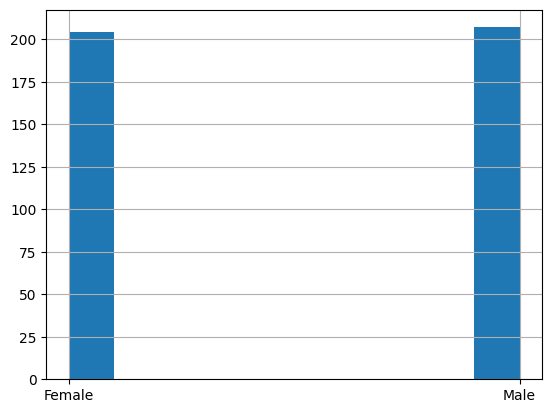

In [6]:
dataset["What is your gender?"].hist()

## 🗑️ অপ্রয়োজনীয় Column Drop করা — `Timestamp`

`Timestamp` Column টি শুধু Survey জমা দেওয়ার সময় রেকর্ড করে — এটি ML Model Training-এ কোনো কাজে আসে না, তাই বাদ দেওয়া হচ্ছে।

### `drop()` এর Parameter ব্যাখ্যা:

| Parameter | মান | অর্থ |
|---|---|---|
| Column নাম | `"Timestamp"` | কোন Column মুছবো |
| `axis` | `1` | Column মুছবো (0 হলে Row মুছতো) |
| `inplace` | `True` | Original DataFrame-এই পরিবর্তন করো |

### `inplace=True` কেন জরুরি?

**inplace=True মানে হলো — পরিবর্তনটা সরাসরি original dataframe এ করে ফেলো, আলাদা কোনো copy বানিয়ো না।** ✅

| | Code | ফলাফল |
|---|---|---|
| `inplace=True` দিলে | `dataset.drop("Timestamp", axis=1, inplace=True)` | `dataset` নিজেই বদলে যাবে |
| `inplace=True` না দিলে | `dataset.drop("Timestamp", axis=1)` | `dataset` অপরিবর্তিত থাকবে, নতুন DataFrame return হবে |
| বিকল্প পদ্ধতি | `dataset = dataset.drop("Timestamp", axis=1)` | Return হওয়া DataFrame কে আবার assign করতে হবে |

> ⚠️ **সবচেয়ে সাধারণ ভুল:** `inplace=True` না দিয়ে শুধু `dataset.drop(...)` লিখলে মনে হয় কাজ হয়েছে, কিন্তু `dataset` প্রিন্ট করলে দেখা যাবে Column এখনো আছে!

In [7]:
# dataset.drop("Timestamp")
# eikhane timestamp ke row onujai khuja hoy.Tohn axis er man 0 thake .but eita ase row onujai. tai axis=1 hbe. but tateo hbe na. implace true lagbe
dataset.drop("Timestamp",axis=1,inplace=True)

In [8]:
dataset

,What is your name?,What is your age?,What is your gender?,A child should sleep?,"At what ages do food allergies, iron deficiency and occur in children?",During the early growing stage of a child the cause of malnutrition according to you is-,Child nutrition can also effect by,During puberty most of the child need to take proper amount of nutrients because,The most important nutrition source of an infant or baby is breast feeding. Without breast feeding they can be grownup but do you think it can be,A girl child needs to have best care during puberty,The most common malnutrition of children in our country,Do you prefer parental awareness in case of a sound health of a child,Nutrition of a child related to,Diarrhea is a very common disease of infant. According to you it happens due to,Some people think that feeding a child more and more Can increase their body growth. But according to you it is a,"Whole grain foods such as breads, cereals that are high in Fibre",Toddlers & preschoolers should have following nutrients in their diet
0,Ayesha Siraji Shejuty,21,Female,8 to 9 hrs,3 to 6 year,Poverty,Quantity of intake food,They have started to growing,Malnutrition,Due to her mental health,Rickets,Strongly agree,Quantity of nutrients,Lack of cleanliness to the instruments that ar...,Cause of malnutrition,Making stool,Milk for the growth but sometimes it causes mi...
1,Nushrah Ipshita,18,Female,8 to 9 hrs,3 to 6 year,Poverty,Environment,They have started to growing,Malnutrition,Due to her mental health,Marasmus,Strongly agree,Quantity of nutrients,Unhealthy environment,Cause of malnutrition,Making stool,Milk for the growth but sometimes it causes mi...
2,Nabhan Ezaz Ilhan,18,Male,8 to 9 hrs,3 to 6 year,Lack of parental awareness,Family care,The growth rate is massive in this period,No if proper nutrients is getting by other foo...,Attractions towards uncertainty,Marasmus,Strongly agree,"Including vegetables, fruits",Lack of cleanliness to the instruments that ar...,Cause of malnutrition,Making stool,Milk for the growth but sometimes it causes mi...
3,Rashedul Hoque Robin,23,Male,8 to 9 hrs,3 to 6 year,Lack of parental awareness,Environment,They have started to growing,No if proper nutrients is getting by other foo...,Due to her mental health,Rickets,Agree,"Including vegetables, fruits",Unhealthy environment,Overweight,Helps bone growth,Calcium for bone growth
4,Mubashira Hoque,22,Female,9 to 10 hrs,3 to 6 year,Poverty,Family care,They have started to growing,Malnutrition,Physiological change,Rickets,Agree,Quantity of nutrients,Lack of cleanliness to the instruments that ar...,Overweight,Making stool,Calcium for bone growth
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,Nila rahman,19,Female,8 to 9 hrs,3 to 6 year,Poverty,Physical well-being,They have started to growing,Malnutrition,Due to her mental health,Rickets,Strongly agree,Quantity of nutrients,Unhealthy environment,Cause of malnutrition,Helps bone growth,Calcium for bone growth
407,Abayat Rahman,21,Male,8 to 9 hrs,1 to 3 year,Poverty,Family care,They have started to growing,No if proper nutrients is getting by other foo...,Attractions towards uncertainty,Rickets,Strongly agree,Quantity of nutrients,Lack of cleanliness to the instruments that ar...,Overweight,Helps bone growth,Calcium for bone growth
408,Talha Ahmed,23,Male,8 to 9 hrs,1 to 3 year,Lack of parental awareness,Environment,They have started to growing,Malnutrition,Due to her mental health,Rickets,Strongly agree,Quantity of nutrients,Lack of cleanliness to the instruments that ar...,Cause of malnutrition,Making stool,Calcium for bone growth
409,Latifur Rahman,21,Male,8 to 9 hrs,1 to 3 year,Lack of parental awareness,Environment,They have started to growing,No if proper nutrients is getting by other foo...,Attractions towards uncertainty,Kwashiorkor,Strongly agree,Milk as a supplement,Lack of cleanliness to the instruments that ar...,Cause of malnutrition,Making stool,Calcium for bone growt

## 🗑️ `Name` Column Drop করা

`What is your name?` Column টিও ML Model-এ কোনো কাজে আসে না — প্রতিটি মানুষের নাম Unique, তাই এটি কোনো Pattern শেখাতে পারে না। বাদ দেওয়া হচ্ছে।

In [9]:
dataset.drop("What is your name?", axis=1, inplace=True)

dataset

,What is your age?,What is your gender?,A child should sleep?,"At what ages do food allergies, iron deficiency and occur in children?",During the early growing stage of a child the cause of malnutrition according to you is-,Child nutrition can also effect by,During puberty most of the child need to take proper amount of nutrients because,The most important nutrition source of an infant or baby is breast feeding. Without breast feeding they can be grownup but do you think it can be,A girl child needs to have best care during puberty,The most common malnutrition of children in our country,Do you prefer parental awareness in case of a sound health of a child,Nutrition of a child related to,Diarrhea is a very common disease of infant. According to you it happens due to,Some people think that feeding a child more and more Can increase their body growth. But according to you it is a,"Whole grain foods such as breads, cereals that are high in Fibre",Toddlers & preschoolers should have following nutrients in their diet
0,21,Female,8 to 9 hrs,3 to 6 year,Poverty,Quantity of intake food,They have started to growing,Malnutrition,Due to her mental health,Rickets,Strongly agree,Quantity of nutrients,Lack of cleanliness to the instruments that ar...,Cause of malnutrition,Making stool,Milk for the growth but sometimes it causes mi...
1,18,Female,8 to 9 hrs,3 to 6 year,Poverty,Environment,They have started to growing,Malnutrition,Due to her mental health,Marasmus,Strongly agree,Quantity of nutrients,Unhealthy environment,Cause of malnutrition,Making stool,Milk for the growth but sometimes it causes mi...
2,18,Male,8 to 9 hrs,3 to 6 year,Lack of parental awareness,Family care,The growth rate is massive in this period,No if proper nutrients is getting by other foo...,Attractions towards uncertainty,Marasmus,Strongly agree,"Including vegetables, fruits",Lack of cleanliness to the instruments that ar...,Cause of malnutrition,Making stool,Milk for the growth but sometimes it causes mi...
3,23,Male,8 to 9 hrs,3 to 6 year,Lack of parental awareness,Environment,They have started to growing,No if proper nutrients is getting by other foo...,Due to her mental health,Rickets,Agree,"Including vegetables, fruits",Unhealthy environment,Overweight,Helps bone growth,Calcium for bone growth
4,22,Female,9 to 10 hrs,3 to 6 year,Poverty,Family care,They have started to growing,Malnutrition,Physiological change,Rickets,Agree,Quantity of nutrients,Lack of cleanliness to the instruments that ar...,Overweight,Making stool,Calcium for bone growth
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,19,Female,8 to 9 hrs,3 to 6 year,Poverty,Physical well-being,They have started to growing,Malnutrition,Due to her mental health,Rickets,Strongly agree,Quantity of nutrients,Unhealthy environment,Cause of malnutrition,Helps bone growth,Calcium for bone growth
407,21,Male,8 to 9 hrs,1 to 3 year,Poverty,Family care,They have started to growing,No if proper nutrients is getting by other foo...,Attractions towards uncertainty,Rickets,Strongly agree,Quantity of nutrients,Lack of cleanliness to the instruments that ar...,Overweight,Helps bone growth,Calcium for bone growth
408,23,Male,8 to 9 hrs,1 to 3 year,Lack of parental awareness,Environment,They have started to growing,Malnutrition,Due to her mental health,Rickets,Strongly agree,Quantity of nutrients,Lack of cleanliness to the instruments that ar...,Cause of malnutrition,Making stool,Calcium for bone growth
409,21,Male,8 to 9 hrs,1 to 3 year,Lack of parental awareness,Environment,They have started to growing,No if proper nutrients is getting by other foo...,Attractions towards uncertainty,Kwashiorkor,Strongly agree,Milk as a supplement,Lack of cleanliness to the instruments that ar...,Cause of malnutrition,Making stool,Calcium for bone growth


# 🔢 Label Encoding — Text কে Number এ রূপান্তর

## 🧠 বিস্তারিত থিওরি

**Doing Label Encoding** ✅

**Label Encoding** হলো Categorical Data (Text) কে Numerical Data (সংখ্যা) তে রূপান্তরের পদ্ধতি।

### কেন Numerical হওয়া দরকার?
ML Algorithms গণিতের উপর ভিত্তি করে কাজ করে — Addition, Multiplication, Distance Calculation ইত্যাদি। এগুলো Text দিয়ে সম্ভব নয়, তাই সব Text মানকে Number এ বদলাতে হয়।

### Label Encoding কীভাবে কাজ করে?
["Female", "Male", "Male", "Female"]

→ Alphabetical Sort: Female=0, Male=1

→ [0, 1, 1, 0]

### `fit_transform()` এর দুটি কাজ:

| ধাপ | কাজ |
|---|---|
| `fit()` | Column-এর সব Unique মান দেখে এবং প্রতিটিকে একটি সংখ্যা assign করে |
| `transform()` | সেই সংখ্যা অনুযায়ী পুরো Column-কে রূপান্তর করে |

> ⚠️ **Label Encoding-এর সীমাবদ্ধতা:** Label Encoding এমন একটি সমস্যা তৈরি করতে পারে যেখানে Model মনে করে বড় সংখ্যা = বেশি গুরুত্বপূর্ণ। যেমন `2 > 1 > 0` — কিন্তু "Agree", "Disagree", "Neutral" এর মধ্যে কোনো Ranking নেই। এই সমস্যার সমাধান হলো **One-Hot Encoding** (পরের Class-এ শেখা হবে)।

> ✅ **কখন Label Encoding ঠিক আছে?** যখন Column-এ Natural Order থাকে — যেমন: Low=0, Medium=1, High=2।

In [10]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

## 👤 Gender Column — Label Encoding

**Gender column** ✅

`le.fit_transform()` দিয়ে `"What is your gender?"` Column-এর Text মানগুলো (Male/Female) সংখ্যায় রূপান্তর করা হচ্ছে এবং সরাসরি সেই Column-এই লিখে দেওয়া


In [11]:
dataset["What is your gender?"]=le.fit_transform(dataset["What is your gender?"])
dataset["What is your gender?"]

,What is your gender?
0,0
1,0
2,1
3,1
4,0
...,...
406,0
407,1
408,1
409,1


## 😴 Sleep Column — Label Encoding

**A child should sleep?** ✅

শিশুর ঘুমের সময় সংক্রান্ত প্রশ্নের উত্তর Encode করা হচ্ছে।

In [12]:
dataset["A child should sleep?"] = le.fit_transform(dataset["A child should sleep?"])
dataset["A child should sleep?"]

,A child should sleep?
0,1
1,1
2,1
3,1
4,2
...,...
406,1
407,1
408,1
409,1


## 🤧 Food Allergy Column — Label Encoding

**At what ages do food allergies, iron deficiency and occur in children?** ✅

শিশুদের খাদ্য অ্যালার্জি ও আয়রনের ঘাটতি সংক্রান্ত প্রশ্নের উত্তর Encode করা হচ্ছে।

In [13]:
dataset["At what ages do food allergies, iron deficiency and occur in children?"] = le.fit_transform(dataset["At what ages do food allergies, iron deficiency and occur in children?"])
dataset["At what ages do food allergies, iron deficiency and occur in children?"]



,"At what ages do food allergies, iron deficiency and occur in children?"
0,1
1,1
2,1
3,1
4,1
...,...
406,1
407,0
408,0
409,0


## 🥗 Malnutrition Cause Column — Label Encoding

**During the early growing stage of a child the cause of malnutrition according to you is-** ✅

শিশুর বিকাশকালীন সময়ে অপুষ্টির কারণ সংক্রান্ত মতামত Encode করা হচ্ছে।

In [14]:
dataset["During the early growing stage of a child the cause of malnutrition according to you is-"] = le.fit_transform(dataset["During the early growing stage of a child the cause of malnutrition according to you is-"])
dataset["During the early growing stage of a child the cause of malnutrition according to you is-"]

,During the early growing stage of a child the cause of malnutrition according to you is-
0,2
1,2
2,0
3,0
4,2
...,...
406,2
407,2
408,0
409,0


## 🌍 Child Nutrition Effect Column — Label Encoding

**Child nutrition can also effect by** ✅

কী কী বিষয় শিশুর পুষ্টিকে প্রভাবিত করে — সেই উত্তর Encode করা হচ্ছে।


```
But we will not encode this because this is our Dependent Column
```



In [15]:
# dataset["Child nutrition can also effect by"] = le.fit_transform(dataset["Child nutrition can also effect by"])
dataset["Child nutrition can also effect by"]

,Child nutrition can also effect by
0,Quantity of intake food
1,Environment
2,Family care
3,Environment
4,Family care
...,...
406,Physical well-being
407,Family care
408,Environment
409,Environment


## 🌱 Puberty Nutrients Column — Label Encoding

**During puberty most of the child need to take proper amount of nutrients because** ✅

বয়ঃসন্ধিকালে সঠিক পুষ্টির প্রয়োজনীয়তা সম্পর্কিত উত্তর Encode করা হচ্ছে।

In [16]:
dataset["During puberty most of the child need to take proper amount of nutrients because"] = le.fit_transform(dataset["During puberty most of the child need to take proper amount of nutrients because"])
dataset["During puberty most of the child need to take proper amount of nutrients because"]

,During puberty most of the child need to take proper amount of nutrients because
0,2
1,2
2,1
3,2
4,2
...,...
406,2
407,2
408,2
409,2


## 🤱 Breastfeeding Column — Label Encoding

**The most important nutrition source of an infant or baby is breast feeding...** ✅

বুকের দুধ খাওয়ানো সংক্রান্ত মতামত Encode করা হচ্ছে।

In [17]:
dataset["The most important nutrition source of  an infant or baby is breast feeding. Without breast feeding they can be grownup but do you think it can be"] = le.fit_transform(dataset["The most important nutrition source of  an infant or baby is breast feeding. Without breast feeding they can be grownup but do you think it can be"])
dataset["The most important nutrition source of  an infant or baby is breast feeding. Without breast feeding they can be grownup but do you think it can be"]

,The most important nutrition source of an infant or baby is breast feeding. Without breast feeding they can be grownup but do you think it can be
0,0
1,0
2,1
3,1
4,0
...,...
406,0
407,1
408,0
409,1


## 👧 Girl Child Puberty Column — Label Encoding

**A girl child needs to have best care during puberty** ✅

মেয়ে শিশুর বয়ঃসন্ধিকালীন যত্ন সংক্রান্ত উত্তর Encode করা হচ্ছে।

In [18]:
dataset["A girl child needs to have best care during puberty"] = le.fit_transform(dataset["A girl child needs to have best care during puberty"])
dataset["A girl child needs to have best care during puberty"]

,A girl child needs to have best care during puberty
0,1
1,1
2,0
3,1
4,2
...,...
406,1
407,0
408,1
409,0


## 🇧🇩 Common Malnutrition Column — Label Encoding

**The most common malnutrition of children in our country** ✅

আমাদের দেশে শিশুদের সবচেয়ে সাধারণ অপুষ্টির ধরন সম্পর্কিত উত্তর Encode করা হচ্ছে।

In [19]:
dataset["The most common malnutrition of children in our country"] = le.fit_transform(dataset["The most common malnutrition of children in our country"])
dataset["The most common malnutrition of children in our country"]

,The most common malnutrition of children in our country
0,2
1,1
2,1
3,2
4,2
...,...
406,2
407,2
408,2
409,0


## 👨‍👩‍👧 Parental Awareness Column — Label Encoding

**Do you prefer parental awareness in case of a sound health of a child** ✅

শিশুর সুস্বাস্থ্যের জন্য অভিভাবকের সচেতনতার গুরুত্ব সম্পর্কিত উত্তর Encode করা হচ্ছে।

In [20]:
dataset["Do you prefer parental awareness in case of a sound health of a child"] = le.fit_transform(dataset["Do you prefer parental awareness in case of a sound health of a child"])
dataset["Do you prefer parental awareness in case of a sound health of a child"]

,Do you prefer parental awareness in case of a sound health of a child
0,2
1,2
2,2
3,0
4,0
...,...
406,2
407,2
408,2
409,2


## 🔗 Nutrition Related Column — Label Encoding

**Nutrition of a child related to** ✅

শিশুর পুষ্টি কী কী বিষয়ের সাথে সম্পর্কিত — সেই উত্তর Encode করা হচ্ছে।

In [21]:
dataset["Nutrition of a child related to"] = le.fit_transform(dataset["Nutrition of a child related to"])
dataset["Nutrition of a child related to"]

,Nutrition of a child related to
0,2
1,2
2,0
3,0
4,2
...,...
406,2
407,2
408,2
409,1


## 🦠 Diarrhea Column — Label Encoding

**Diarrhea is a very common disease of infant. According to you it happens due to** ✅

শিশুদের ডায়রিয়ার কারণ সম্পর্কিত মতামত Encode করা হচ্ছে।

In [22]:
dataset["Diarrhea is a very common disease of infant. According to you it happens due to"] = le.fit_transform(dataset["Diarrhea is a very common disease of infant. According to you it happens due to"])
dataset["Diarrhea is a very common disease of infant. According to you it happens due to"]

,Diarrhea is a very common disease of infant. According to you it happens due to
0,0
1,2
2,0
3,2
4,0
...,...
406,2
407,0
408,0
409,0


## 🍔 Overfeeding Column — Label Encoding

**Some people think that feeding a child more and more Can increase their body growth. But according to you it is a** ✅

অতিরিক্ত খাওয়ানো শিশুর বৃদ্ধিতে সাহায্য করে কিনা — সেই মতামত Encode করা হচ্ছে।

In [23]:
dataset["Some people think that feeding a child more and more Can increase their body growth. But according to you it is a"] = le.fit_transform(dataset["Some people think that feeding a child more and more Can increase their body growth. But according to you it is a"])
dataset["Some people think that feeding a child more and more Can increase their body growth. But according to you it is a"]

,Some people think that feeding a child more and more Can increase their body growth. But according to you it is a
0,0
1,0
2,0
3,2
4,2
...,...
406,0
407,2
408,0
409,0


## 🌾 Whole Grain Column — Label Encoding

**Whole grain foods such as breads, cereals that are high in Fibre** ✅

আঁশযুক্ত শস্যজাতীয় খাবার সম্পর্কিত উত্তর Encode করা হচ্ছে।

In [24]:
dataset["Whole grain foods such as breads, cereals that are high in Fibre"] = le.fit_transform(dataset["Whole grain foods such as breads, cereals that are high in Fibre"])
dataset["Whole grain foods such as breads, cereals that are high in Fibre"]

,"Whole grain foods such as breads, cereals that are high in Fibre"
0,3
1,3
2,3
3,0
4,3
...,...
406,0
407,0
408,3
409,3


## 🥦 Toddlers Nutrients Column — Label Encoding

**Toddlers & preschoolers should have following nutrients in their diet** ✅

ছোট শিশুদের (Toddler ও Preschooler) খাদ্যতালিকায় কোন কোন পুষ্টি থাকা দরকার — সেই মতামত Encode করা হচ্ছে।

In [25]:
dataset["Toddlers & preschoolers should have following nutrients in their diet"] = le.fit_transform(dataset["Toddlers & preschoolers should have following nutrients in their diet"])
dataset["Toddlers & preschoolers should have following nutrients in their diet"]

,Toddlers & preschoolers should have following nutrients in their diet
0,1
1,1
2,1
3,0
4,0
...,...
406,0
407,0
408,0
409,0


## ✅ Final Dataset দেখা — সব Encoding সম্পন্ন

`head(20)` দিয়ে প্রথম ২০টি Row দেখা হচ্ছে — এখন সব Column-এ Text-এর বদলে **সংখ্যা** দেখা যাবে। Dataset এখন ML Model-এ দেওয়ার জন্য প্রস্তুত।

---

# 🏁 চূড়ান্ত সারসংক্ষেপ (Final Summary)

| বিষয় | কী শিখলাম |
|---|---|
| **`value_counts()`** | প্রতিটি Unique মান কতবার আছে গণনা করে |
| **`drop(axis=1)`** | Column মুছে ফেলা |
| **`inplace=True`** | Original DataFrame-এই পরিবর্তন সংরক্ষণ |
| **`LabelEncoder`** | Text → Number রূপান্তর |
| **`fit_transform()`** | Unique মান শিখে একসাথে Encode করে |
| **Label Encoding সীমাবদ্ধতা** | Ordinal Ranking তৈরি করে, Nominal Data-তে সমস্যা |

> ⭐ যদি এই নোটবুকটি ভালো লাগে, GitHub-এ Star দিতে ভুলো না!

In [26]:
dataset.head(20)

,What is your age?,What is your gender?,A child should sleep?,"At what ages do food allergies, iron deficiency and occur in children?",During the early growing stage of a child the cause of malnutrition according to you is-,Child nutrition can also effect by,During puberty most of the child need to take proper amount of nutrients because,The most important nutrition source of an infant or baby is breast feeding. Without breast feeding they can be grownup but do you think it can be,A girl child needs to have best care during puberty,The most common malnutrition of children in our country,Do you prefer parental awareness in case of a sound health of a child,Nutrition of a child related to,Diarrhea is a very common disease of infant. According to you it happens due to,Some people think that feeding a child more and more Can increase their body growth. But according to you it is a,"Whole grain foods such as breads, cereals that are high in Fibre",Toddlers & preschoolers should have following nutrients in their diet
0,21,0,1,1,2,Quantity of intake food,2,0,1,2,2,2,0,0,3,1
1,18,0,1,1,2,Environment,2,0,1,1,2,2,2,0,3,1
2,18,1,1,1,0,Family care,1,1,0,1,2,0,0,0,3,1
3,23,1,1,1,0,Environment,2,1,1,2,0,0,2,2,0,0
4,22,0,2,1,2,Family care,2,0,2,2,0,2,0,2,3,0
5,23,1,2,2,0,Family care,2,2,2,2,2,0,1,2,2,0
6,24,1,1,0,0,Environment,1,0,0,2,0,2,0,0,0,0
7,20,0,1,2,0,Physical well-being,0,0,2,2,0,2,0,1,3,0
8,24,1,2,1,2,Family care,2,2,2,0,0,2,2,2,0,2
9,22,0,1,2,2,Environment,1,0,0,2,0,2,2,1,2,2


## ⚠️ একটি গুরুত্বপূর্ণ পার্থক্য — Class 05 vs Class 06

Class 05-এ আমরা **"Child nutrition can also effect by"** Column-টিকেও Label Encode করেছিলাম।

কিন্তু Class 06-এ আমরা বুঝলাম — এই Column-টি আসলে আমাদের **Target (Y/Dependent Variable)**! অর্থাৎ এটাই আমরা Predict করতে চাই।

**Eita dependent tai "Child nutrition can also effect by" ke label encoding korbo na** ✅

তাই Class 06-এ এই Column-টি Label Encode করা হয়নি — এটিকে সরাসরি `y` হিসেবে রাখা হয়েছে।

---

# 🤖 Class 06 — Supervised ML Algorithms দিয়ে Classification

## 📌 ভূমিকা (Introduction)

Class 05 পর্যন্ত আমরা Data Preparation সম্পন্ন করেছি। এখন আসল কাজ শুরু — **Machine Learning Model Train করা**।

এই Class-এ আমরা **১৩টি বিভিন্ন Supervised ML Algorithm** একের পর এক Apply করব এবং দেখব কোনটি সবচেয়ে বেশি Accurate Prediction করতে পারে।

### আমাদের লক্ষ্য (Our Task):
- Dependent (Y) ও Independent (X) Variable আলাদা করা
- Train-Test Split করা
- ১৩টি Algorithm দিয়ে Model Train ও Predict করা
- **Accuracy Score, Classification Report, Confusion Matrix** দিয়ে প্রতিটি মডেল যাচাই করা
- সব মডেলের Accuracy একসাথে Compare করা এবং সেরাটি বেছে নেওয়া

---

### 🧠 Supervised vs Unsupervised Learning — পার্থক্য কী?

ধরো তুমি একটি বাচ্চাকে ছবি দেখিয়ে শেখাচ্ছ — "এটা বিড়াল, এটা কুকুর।" বাচ্চাটি Label সহ শিখছে।

এটাই **Supervised Learning** — প্রতিটি ডেটার সাথে **সঠিক উত্তর (Label)** দেওয়া থাকে, Algorithm সেই প্রশ্ন-উত্তর জোড়া দেখে শেখে।

আর **Unsupervised Learning** হলো — বাচ্চাকে অনেক ছবি দিলে, কিন্তু কোনো Label নেই। বাচ্চা নিজে নিজে মিল খুঁজে বের করে গ্রুপ করে।

| | Supervised | Unsupervised |
|---|---|---|
| Label আছে? | ✅ হ্যাঁ | ❌ নেই |
| উদাহরণ | Classification, Regression | Clustering |
| আমরা এখন করছি | ✅ | |

### 🎯 Classification কী?

আমাদের Target (`y`) হলো **"Child nutrition can also effect by"** — যেটায় কয়েকটি নির্দিষ্ট Category আছে। যখন Output Categorical (নির্দিষ্ট Class) হয়, তখন সেটাকে **Classification Problem** বলে।

> **Regression** → Output সংখ্যা (যেমন দাম, তাপমাত্রা)
> **Classification** → Output Category/Class (যেমন হ্যাঁ/না, গ্রুপ A/B/C)

## 🔍 Dependent Column চিহ্নিত করা — `dataset.columns[5]`

`dataset.columns` হলো Dataset-এর সব Column-এর নামের List। `[5]` দিয়ে 5 নম্বর Index (0 থেকে গণনা) মানে **ষষ্ঠ Column** এর নাম দেখা হচ্ছে।

এই Column-টিই আমাদের **Dependent (Target/Y) Variable** — যেটা আমরা Predict করতে চাই।

> 💡 **কেন Index 5?** Dataset-এ Column গুলো 0 থেকে গণনা শুরু হয়। 5 মানে ৬ষ্ঠ Column। এটা আগে চেক করে নেওয়া হচ্ছে যাতে নিশ্চিত হওয়া যায় সঠিক Column-টিই Target হিসেবে নেওয়া হচ্ছে।

In [27]:
dataset.columns[5]

'Child nutrition can also effect by'

## 📥 X (Independent Variables) তৈরি করা

`dataset.drop(dataset.columns[5], axis=1)` — মানে **5 নম্বর Column (Target Column) বাদ দিয়ে** বাকি সব Column নিয়ে `x` তৈরি করা হচ্ছে।

### কেন এইভাবে X তৈরি করলাম?

এই Dataset-এ অনেক Column আছে। সব Column-এর নাম টাইপ করা কঠিন, তাই সহজ উপায় হলো — শুধু Target Column-টি বাদ দিয়ে বাকি সব নেওয়া।

> ⚠️ **সাধারণ ভুল:** `drop()` এ `inplace=True` দেওয়া হয়নি কারণ এখানে `dataset` পরিবর্তন করতে চাই না — শুধু `x` নামে একটি নতুন Variable তৈরি করতে চাই। যদি `inplace=True` দিতাম, তাহলে `dataset` থেকে সেই Column সবসময়ের জন্য মুছে যেত।

In [29]:
x= dataset.drop(["Child nutrition can also effect by"],axis=1)
x
# x=dataset.drop(dataset.columns[5], axis=1)

,What is your age?,What is your gender?,A child should sleep?,"At what ages do food allergies, iron deficiency and occur in children?",During the early growing stage of a child the cause of malnutrition according to you is-,During puberty most of the child need to take proper amount of nutrients because,The most important nutrition source of an infant or baby is breast feeding. Without breast feeding they can be grownup but do you think it can be,A girl child needs to have best care during puberty,The most common malnutrition of children in our country,Do you prefer parental awareness in case of a sound health of a child,Nutrition of a child related to,Diarrhea is a very common disease of infant. According to you it happens due to,Some people think that feeding a child more and more Can increase their body growth. But according to you it is a,"Whole grain foods such as breads, cereals that are high in Fibre",Toddlers & preschoolers should have following nutrients in their diet
0,21,0,1,1,2,2,0,1,2,2,2,0,0,3,1
1,18,0,1,1,2,2,0,1,1,2,2,2,0,3,1
2,18,1,1,1,0,1,1,0,1,2,0,0,0,3,1
3,23,1,1,1,0,2,1,1,2,0,0,2,2,0,0
4,22,0,2,1,2,2,0,2,2,0,2,0,2,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,19,0,1,1,2,2,0,1,2,2,2,2,0,0,0
407,21,1,1,0,2,2,1,0,2,2,2,0,2,0,0
408,23,1,1,0,0,2,0,1,2,2,2,0,0,3,0
409,21,1,1,0,0,2,1,0,0,2,1,0,0,3,0


## 📤 Y (Dependent/Target Variable) তৈরি করা

`y` হলো আমাদের **উত্তর** — মডেল এই `y` দেখে শিখবে এবং পরে নতুন ডেটায় এই Column-এর মান Predict করার চেষ্টা করবে।

এটি এখনো Text/Categorical আকারে আছে — কিন্তু Scikit-learn এর অনেক Classifier Text Label-এ কাজ করতে পারে, তাই এখানে আলাদা Encoding করার দরকার নেই।

In [30]:
y=dataset["Child nutrition can also effect by"]
y

,Child nutrition can also effect by
0,Quantity of intake food
1,Environment
2,Family care
3,Environment
4,Family care
...,...
406,Physical well-being
407,Family care
408,Environment
409,Environment


## ✂️ Train-Test Split

### 🧠 কেন Split করতে হয়? — একদম সহজ উদাহরণ

ধরো তুমি পরীক্ষার আগে Practice Question পড়লে (Training)। পরীক্ষায় নতুন Question আসে (Testing)। যদি পরীক্ষায় Practice এর একই Question আসে, তাহলে বোঝা যাবে না তুমি আসলেই শিখেছ কিনা।

ML Model-এও একই ব্যাপার:
- **Training Data** → Model এই Data দেখে শেখে (Practice Question)
- **Testing Data** → Model কখনো এই Data দেখেনি (Exam Question)

| Parameter | মান | মানে |
|---|---|---|
| `test_size=0.2` | 20% | মোট Data-র 20% Test-এর জন্য রাখা |
| `random_state=0` | 0 | প্রতিবার একই Split হবে (Reproducibility) |

$$\text{Training Data} = 80\% \quad \text{Testing Data} = 20\%$$

In [31]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.2,random_state=0)

# 🌳 Supervised Algorithms — একে একে প্রতিটি Algorithm

## 🧠 Accuracy, Classification Report, Confusion Matrix — এই তিনটি কী?

প্রতিটি Model Train করার পর আমরা তিনটি জিনিস দিয়ে মডেল যাচাই করব:

### 1️⃣ Accuracy Score
$$\text{Accuracy} = \frac{\text{সঠিক Prediction সংখ্যা}}{\text{মোট Prediction সংখ্যা}}$$

সহজ কথায়: ১০০টি Test-এর মধ্যে কতটা সঠিক হলো।

### 2️⃣ Classification Report
প্রতিটি Class-এর জন্য আলাদা আলাদা তিনটি Metric দেখায়:

| Metric | সূত্র | মানে |
|---|---|---|
| **Precision** | $\frac{TP}{TP+FP}$ | যা Positive বলেছি, তার মধ্যে কতটা আসলে Positive |
| **Recall** | $\frac{TP}{TP+FN}$ | আসল Positive-দের মধ্যে কতটা ধরতে পেরেছি |
| **F1-Score** | $\frac{2 \times P \times R}{P+R}$ | Precision ও Recall এর Balance |

### 3️⃣ Confusion Matrix
একটি Table যেখানে দেখা যায় মডেল কোন Class-কে কোন Class ভেবে ভুল করেছে:

| | Predicted Neg | Predicted Pos |
|---|---|---|
| **Actual Neg** | [ TN ] | [ FP ] |
| **Actual Pos** | [ FN ] | [ TP ] |


- **TP** (True Positive): আসলে Positive, বলেছেও Positive ✅
- **TN** (True Negative): আসলে Negative, বলেছেও Negative ✅
- **FP** (False Positive): আসলে Negative, কিন্তু বলেছে Positive ❌
- **FN** (False Negative): আসলে Positive, কিন্তু বলেছে Negative ❌

> 💡 **Accuracy jeita beshi sei model/algorithm ta nibo** ✅ — সব Algorithm চালানোর পর সবচেয়ে বেশি Accuracy যে মডেলের, সেটাই আমরা Final Model হিসেবে বেছে নেব।

---

## 1️⃣ Decision Tree Classifier

### 🧠 বিস্তারিত থিওরি

**Decision Tree** হলো একটি Algorithm যা ডেটাকে ধাপে ধাপে প্রশ্ন করে সিদ্ধান্তে আসে — একটি গাছের মতো, যেখানে প্রতিটি শাখায় একটি প্রশ্ন এবং পাতায় (Leaf) উত্তর।

**সহজ উদাহরণ:**

### 🌳 Decision Tree

* **বাইরে যাব?**
    * **বৃষ্টি আছে?**
        * হ্যাঁ → ছাতা নেব
        * না → কোনো ছাতা লাগবে না
    * **রোদ আছে?**
        * হ্যাঁ → সানগ্লাস নেব
        * না → স্বাভাবিক পোশাক

### কীভাবে "সেরা প্রশ্ন" বেছে নেয়?

Decision Tree **Gini Impurity** বা **Information Gain** ব্যবহার করে বুঝে কোন Feature দিয়ে ভাগ করলে ডেটা সবচেয়ে বেশি পরিষ্কার হয়।

$$\text{Gini} = 1 - \sum_{i=1}^{n} p_i^2$$

যেখানে $p_i$ = প্রতিটি Class-এর সম্ভাব্যতা।

### সুবিধা:
- সহজে বোঝা যায় (কোন পথে কী সিদ্ধান্ত হচ্ছে দেখা যায়)
- Normalization দরকার নেই
- Numerical ও Categorical উভয় Data-তে কাজ করে

### সমস্যা:
- **Overfitting** — Training Data-তে অনেক ভালো কিন্তু নতুন Data-তে খারাপ করতে পারে
- ছোট পরিবর্তনে পুরো Tree পরিবর্তন হয়ে যেতে পারে

> ⚠️ **সাধারণ ভুল:** `DecisionTreeClassifier()` কোনো parameter ছাড়া দিলে Unlimited Depth-এ Tree তৈরি হয় → Overfitting বাড়ে। `max_depth=5` এর মতো Limit দেওয়া ভালো Practice।

In [32]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(x_train,y_train)

ypred=dt.predict(x_test)

from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print(accuracy_score(y_test,ypred))
print(confusion_matrix(y_test,ypred))
print(confusion_matrix(y_test,ypred))


0.4939759036144578
[[23  6  6  2]
 [11 14  6  2]
 [ 1  2  4  2]
 [ 0  2  2  0]]
[[23  6  6  2]
 [11 14  6  2]
 [ 1  2  4  2]
 [ 0  2  2  0]]


🎯 Accuracy Score: 0.4940 (49.40%)
------------------------------------------------------------
📊 Classification Report:


,precision,recall,f1-score,support
Environment,0.66,0.62,0.64,37.00
Family care,0.58,0.42,0.49,33.00
Physical well-being,0.22,0.44,0.30,9.00
Quantity of intake food,0.00,0.00,0.00,4.00
accuracy,0.49,0.49,0.49,0.49
macro avg,0.37,0.37,0.36,83.00
weighted avg,0.55,0.49,0.51,83.00


------------------------------------------------------------
🧩 Confusion Matrix Heatmap:


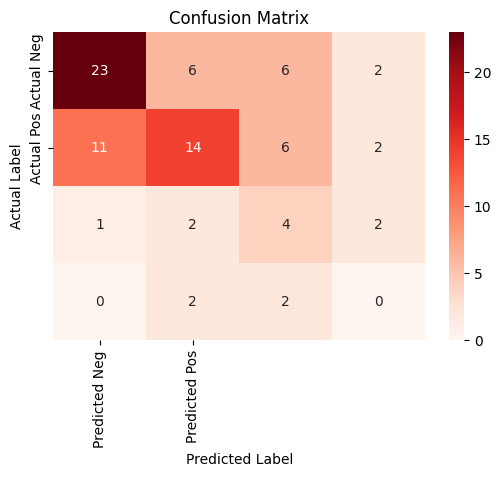

In [36]:
import seaborn as sns

# ১. Accuracy Score প্রিন্ট করা
accuracy = accuracy_score(y_test, ypred)
print(f"🎯 Accuracy Score: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("-" * 60)

# ২. Classification Report-কে সুন্দর টেবিলে রূপান্তর
print("📊 Classification Report:")
report_dict = classification_report(y_test, ypred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
# Colab-এ display() ব্যবহার করলে টেবিলটি দেখতে চমৎকার লাগে
display(report_df.round(2))
print("-" * 60)

# ৩. Confusion Matrix-কে সুন্দর কালারফুল হিটম্যাপে রূপান্তর
print("🧩 Confusion Matrix Heatmap:")
cm = confusion_matrix(y_test, ypred)

plt.figure(figsize=(6, 4))
# annot=True দিলে ঘরের ভেতর সংখ্যা দেখাবে, cmap দিয়ে কালার পরিবর্তন করা যায়
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted Neg', 'Predicted Pos'],
            yticklabels=['Actual Neg', 'Actual Pos'])

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

## 2️⃣ KNN — K-Nearest Neighbors Classifier

### 🧠 বিস্তারিত থিওরি

**KNN** হলো সবচেয়ে সহজ ML Algorithm — এটা বলে: "তোমার কাছের মানুষরা যেরকম, তুমিও সেরকম।"

**সহজ উদাহরণ:**
একটি নতুন ছাত্র স্কুলে এলো। সে কোন গ্রুপে পড়বে? তার কাছের K জন বন্ধু দেখো — তারা যে গ্রুপে বেশি, সে সেই গ্রুপে।

### কীভাবে কাজ করে?

1. নতুন একটি Data Point আসলে, সব Training Data-র সাথে **Distance** মাপো

$$d = \sqrt{(x_2-x_1)^2 + (y_2-y_1)^2}$$  *(Euclidean Distance)*

2. সবচেয়ে **কাছের K টি** Data Point খোঁজো (K=5 ডিফল্ট)
3. সেই K-টার মধ্যে যে Class বেশি, সেই Class-এ নতুন Point-কে রাখো

### সুবিধা:
- Training Phase নেই (Lazy Learner) — সব কাজ Prediction-এর সময় করে
- সহজ ও বোধগম্য

### সমস্যা:
- **Slow** — বড় Dataset-এ প্রতিটি Prediction-এ সব Data-র সাথে Distance মাপে
- **Normalization অবশ্যই লাগে** — না হলে বড় সংখ্যার Feature দূরত্বকে Support করে
- সঠিক K বেছে নেওয়া জরুরি (খুব ছোট K → Noise sensitive, খুব বড় K → সব একই হয়ে যায়)

> ⚠️ **সাধারণ ভুল:** Normalization ছাড়া KNN ব্যবহার করলে ভুল ফলাফল আসতে পারে, কারণ বড় মানের Feature গুলো Distance Calculation-এ বেশি প্রভাব ফেলে।

🎯 Accuracy Score: 0.4699 (46.99%)
------------------------------------------------------------
📊 Classification Report:


,precision,recall,f1-score,support
Environment,0.52,0.81,0.63,37.00
Family care,0.43,0.27,0.33,33.00
Physical well-being,0.00,0.00,0.00,9.00
Quantity of intake food,0.00,0.00,0.00,4.00
accuracy,0.47,0.47,0.47,0.47
macro avg,0.24,0.27,0.24,83.00
weighted avg,0.40,0.47,0.41,83.00


------------------------------------------------------------
🧩 Confusion Matrix Heatmap:


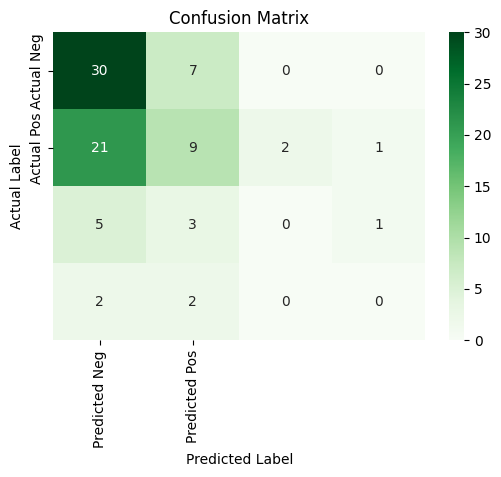

In [38]:
from sklearn.neighbors import KNeighborsClassifier
kc= KNeighborsClassifier()

kc.fit(x_train,y_train)
ypred=kc.predict(x_test)

import seaborn as sns

# ১. Accuracy Score প্রিন্ট করা
accuracy = accuracy_score(y_test, ypred)
print(f"🎯 Accuracy Score: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("-" * 60)

# ২. Classification Report-কে সুন্দর টেবিলে রূপান্তর
print("📊 Classification Report:")
report_dict = classification_report(y_test, ypred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
# Colab-এ display() ব্যবহার করলে টেবিলটি দেখতে চমৎকার লাগে
display(report_df.round(2))
print("-" * 60)

# ৩. Confusion Matrix-কে সুন্দর কালারফুল হিটম্যাপে রূপান্তর
print("🧩 Confusion Matrix Heatmap:")
cm = confusion_matrix(y_test, ypred)

plt.figure(figsize=(6, 4))
# annot=True দিলে ঘরের ভেতর সংখ্যা দেখাবে, cmap দিয়ে কালার পরিবর্তন করা যায়
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted Neg', 'Predicted Pos'],
            yticklabels=['Actual Neg', 'Actual Pos'])

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

## 3️⃣ Random Forest Classifier

### 🧠 বিস্তারিত থিওরি

**Random Forest** হলো অনেকগুলো Decision Tree-এর সমষ্টি — "বনের মতো"। একটি গাছ ভুল করতে পারে, কিন্তু অনেক গাছ মিলে ভোট দিলে সঠিক উত্তর পাওয়ার সম্ভাবনা বাড়ে।

**সহজ উদাহরণ:**
একা একজনের মতামত নেওয়ার চেয়ে ১০০ জনের মতামত নিয়ে Majority Vote নেওয়া ভালো।

### কীভাবে কাজ করে?

1. Training Data থেকে **বারবার Random Sample** নিয়ে অনেকগুলো আলাদা Decision Tree তৈরি করো (**Bagging**)
2. প্রতিটি Tree-তে **Random কিছু Feature** ব্যবহার করো (সব Feature নয়)
3. Prediction-এর সময় সব Tree-র Prediction নিয়ে **Majority Vote** করো

$$\text{Final Prediction} = \text{Mode}(\text{Tree}_1, \text{Tree}_2, ..., \text{Tree}_n)$$

### সুবিধা:
- Decision Tree-র Overfitting সমস্যা অনেক কমে যায়
- Feature Importance বলতে পারে (কোন Feature সবচেয়ে গুরুত্বপূর্ণ)
- Normalization দরকার নেই

### সমস্যা:
- Decision Tree-র চেয়ে ধীর (অনেক Tree তৈরি করতে হয়)
- Memory বেশি লাগে
- Decision Tree-র মতো সহজে Visualize করা যায় না

> ⚠️ **সাধারণ ভুল:** Default `n_estimators=100` (100টি Tree)। ছোট Dataset-এ এত Tree দরকার নাও হতে পারে, আবার বড় Dataset-এ বাড়ানো দরকার হতে পারে।

🎯 Accuracy Score: 0.5422 (54.22%)
------------------------------------------------------------
📊 Classification Report:


,precision,recall,f1-score,support
Environment,0.56,0.78,0.65,37.00
Family care,0.67,0.48,0.56,33.00
Physical well-being,0.00,0.00,0.00,9.00
Quantity of intake food,0.00,0.00,0.00,4.00
accuracy,0.54,0.54,0.54,0.54
macro avg,0.31,0.32,0.30,83.00
weighted avg,0.51,0.54,0.51,83.00


------------------------------------------------------------
🧩 Confusion Matrix Heatmap:


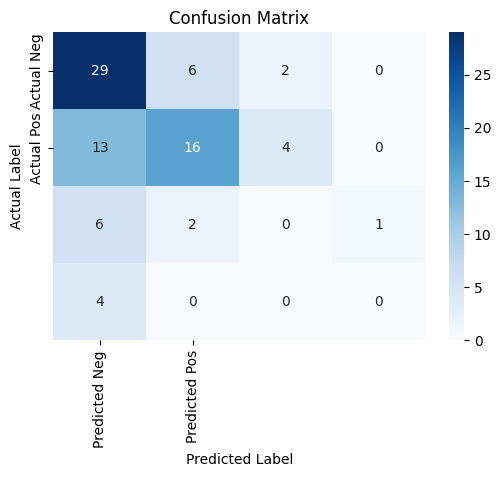

In [42]:
from sklearn.ensemble import RandomForestClassifier
rf= RandomForestClassifier()

rf.fit(x_train,y_train)
ypred=rf.predict(x_test)


# ১. Accuracy Score প্রিন্ট করা
accuracy = accuracy_score(y_test, ypred)
print(f"🎯 Accuracy Score: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("-" * 60)

# ২. Classification Report-কে সুন্দর টেবিলে রূপান্তর
print("📊 Classification Report:")
report_dict = classification_report(y_test, ypred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
# Colab-এ display() ব্যবহার করলে টেবিলটি দেখতে চমৎকার লাগে
display(report_df.round(2))
print("-" * 60)

# ৩. Confusion Matrix-কে সুন্দর কালারফুল হিটম্যাপে রূপান্তর
print("🧩 Confusion Matrix Heatmap:")
cm = confusion_matrix(y_test, ypred)

plt.figure(figsize=(6, 4))
# annot=True দিলে ঘরের ভেতর সংখ্যা দেখাবে, cmap দিয়ে কালার পরিবর্তন করা যায়
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Neg', 'Predicted Pos'],
            yticklabels=['Actual Neg', 'Actual Pos'])

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

## 4️⃣ Logistic Regression

### 🧠 বিস্তারিত থিওরি

নামে "Regression" আছে কিন্তু এটি আসলে **Classification Algorithm** — এটা Continuous সংখ্যা না বলে **Class-এর সম্ভাব্যতা (Probability)** বলে।

**সহজ উদাহরণ:**
ডাক্তার বলছেন: "তোমার এই রোগ হওয়ার সম্ভাবনা ৮০%।" — এটাই Logistic Regression এর কাজ।

### Sigmoid Function — কীভাবে Probability বের করে?

Linear Regression এর Output (যেকোনো সংখ্যা) কে **0 থেকে 1** এর মধ্যে নিয়ে আসতে **Sigmoid Function** ব্যবহার করা হয়:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

- Output **0.5 এর বেশি** → Class 1
- Output **0.5 এর কম** → Class 0

### `max_iter=1000` কেন?

Logistic Regression Iteratively (বারবার) Parameter Optimize করে। Default হলো 100 Iteration — কিন্তু Complex Data-তে 100 Iteration-এ Convergence (সঠিক উত্তরে পৌঁছানো) নাও হতে পারে। তাই `max_iter=1000` দিয়ে বেশি সুযোগ দেওয়া হচ্ছে।

### সুবিধা:
- দ্রুত ও মেমোরি-বান্ধব
- Probability Output দেয় (শুধু Class নয়)
- Linear Relationship ভালো ধরতে পারে

### সমস্যা:
- **Non-linear** Data-তে ভালো কাজ করে না
- **Normalization** দরকার

> ⚠️ **সাধারণ ভুল:** `max_iter` কম দিলে `ConvergenceWarning` আসতে পারে — মডেল সঠিক উত্তরে পৌঁছাতে পারেনি মানে।

🎯 Accuracy Score: 0.4819 (48.19%)
------------------------------------------------------------
📊 Classification Report:


,precision,recall,f1-score,support
Environment,0.54,0.76,0.63,37.00
Family care,0.67,0.36,0.47,33.00
Physical well-being,0.00,0.00,0.00,9.00
Quantity of intake food,0.00,0.00,0.00,4.00
accuracy,0.48,0.48,0.48,0.48
macro avg,0.30,0.28,0.27,83.00
weighted avg,0.51,0.48,0.47,83.00


------------------------------------------------------------
🧩 Confusion Matrix Heatmap:


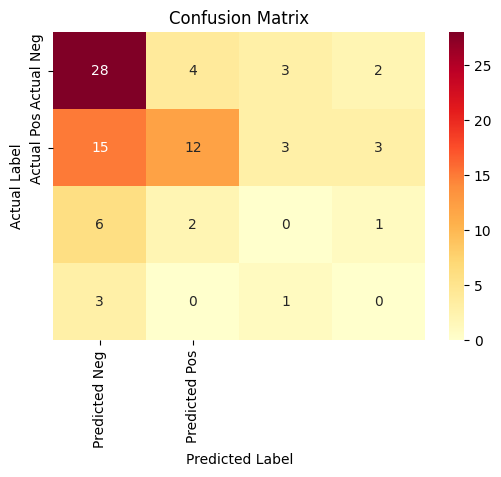

In [44]:
from sklearn.linear_model import LogisticRegression
lr= LogisticRegression(max_iter=1000)

lr.fit(x_train,y_train)
ypred=lr.predict(x_test)

import seaborn as sns

# ১. Accuracy Score প্রিন্ট করা
accuracy = accuracy_score(y_test, ypred)
print(f"🎯 Accuracy Score: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("-" * 60)

# ২. Classification Report-কে সুন্দর টেবিলে রূপান্তর
print("📊 Classification Report:")
report_dict = classification_report(y_test, ypred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
# Colab-এ display() ব্যবহার করলে টেবিলটি দেখতে চমৎকার লাগে
display(report_df.round(2))
print("-" * 60)

# ৩. Confusion Matrix-কে সুন্দর কালারফুল হিটম্যাপে রূপান্তর
print("🧩 Confusion Matrix Heatmap:")
cm = confusion_matrix(y_test, ypred)

plt.figure(figsize=(6, 4))
# annot=True দিলে ঘরের ভেতর সংখ্যা দেখাবে, cmap দিয়ে কালার পরিবর্তন করা যায়
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['Predicted Neg', 'Predicted Pos'],
            yticklabels=['Actual Neg', 'Actual Pos'])

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

## 5️⃣ Support Vector Machine (SVM)

### 🧠 বিস্তারিত থিওরি

**SVM** ডেটাকে আলাদা করার জন্য **সবচেয়ে বড় ফাঁক (Maximum Margin)** সহ একটি **সীমারেখা (Hyperplane)** খোঁজে।

**সহজ উদাহরণ:**
দুটি দলকে আলাদা করার জন্য একটি দেওয়াল তোলো — দেওয়ালটি এমনভাবে তোলো যাতে দুই দলের মধ্যে ফাঁক সবচেয়ে বেশি হয়। সীমার কাছের Points গুলোকে বলে **Support Vectors**।

### ২D ও ৩D তে কীভাবে কাজ করে?

| Data | Boundary |
|---|---|
| 2D (2 Feature) | Line (সরলরেখা) |
| 3D (3 Feature) | Plane (সমতল) |
| nD (n Feature) | Hyperplane |

যদি Data Linear ভাবে আলাদা না করা যায়, SVM **Kernel Trick** ব্যবহার করে ডেটাকে উচ্চতর মাত্রায় নিয়ে Separate করে।

### সুবিধা:
- High Dimensional Data-তে ভালো কাজ করে
- Clear Margin থাকায় Overfitting কম

### সমস্যা:
- বড় Dataset-এ **অনেক ধীর**
- **Normalization অবশ্যই লাগে**
- সঠিক Kernel বেছে নেওয়া কঠিন

> ⚠️ **সাধারণ ভুল:** Normalization ছাড়া SVM ব্যবহার করলে Accuracy অনেক কমে যেতে পারে কারণ SVM Distance-based।

🎯 Accuracy Score: 0.4458 (44.58%)
------------------------------------------------------------
📊 Classification Report:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,precision,recall,f1-score,support
Environment,0.45,1.00,0.62,37.00
Family care,0.00,0.00,0.00,33.00
Physical well-being,0.00,0.00,0.00,9.00
Quantity of intake food,0.00,0.00,0.00,4.00
accuracy,0.45,0.45,0.45,0.45
macro avg,0.11,0.25,0.15,83.00
weighted avg,0.20,0.45,0.27,83.00


------------------------------------------------------------
🧩 Confusion Matrix Heatmap:


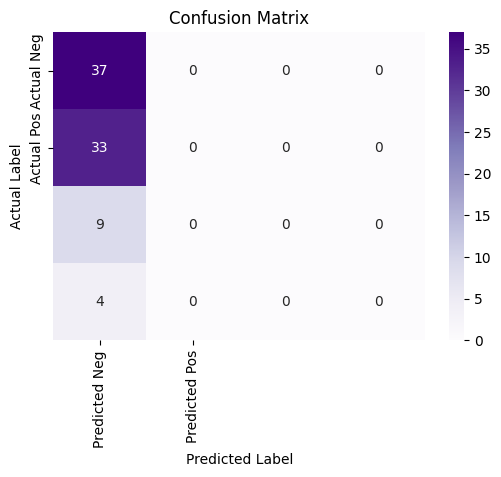

In [45]:
from sklearn.svm import SVC
svm=SVC()

svm.fit(x_train,y_train)
ypred=svm.predict(x_test)


# ১. Accuracy Score প্রিন্ট করা
accuracy = accuracy_score(y_test, ypred)
print(f"🎯 Accuracy Score: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("-" * 60)

# ২. Classification Report-কে সুন্দর টেবিলে রূপান্তর
print("📊 Classification Report:")
report_dict = classification_report(y_test, ypred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
# Colab-এ display() ব্যবহার করলে টেবিলটি দেখতে চমৎকার লাগে
display(report_df.round(2))
print("-" * 60)

# ৩. Confusion Matrix-কে সুন্দর কালারফুল হিটম্যাপে রূপান্তর
print("🧩 Confusion Matrix Heatmap:")
cm = confusion_matrix(y_test, ypred)

plt.figure(figsize=(6, 4))
# annot=True দিলে ঘরের ভেতর সংখ্যা দেখাবে, cmap দিয়ে কালার পরিবর্তন করা যায়
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Predicted Neg', 'Predicted Pos'],
            yticklabels=['Actual Neg', 'Actual Pos'])

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

## 6️⃣ Naive Bayes

### 🧠 বিস্তারিত থিওরি

**Naive Bayes** হলো **Bayes Theorem** ভিত্তিক একটি Probabilistic Algorithm। এটি বলে — প্রতিটি Feature আলাদাভাবে স্বাধীনভাবে Target-এ প্রভাব ফেলে (এই "সরলীকৃত ধারণা"-র জন্যই নাম "Naive")।

**Bayes Theorem:**

$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

সহজ কথায়: "B ঘটেছে জেনে A ঘটার সম্ভাবনা কত?"

**সহজ উদাহরণ:**
Email Spam Filter — "Free", "Win", "Prize" শব্দ থাকলে Spam হওয়ার সম্ভাবনা বেশি। Naive Bayes প্রতিটি শব্দকে আলাদাভাবে দেখে সম্ভাবনা গণনা করে।

**GaussianNB** কেন? — আমাদের Data Continuous Numerical, তাই Gaussian (Normal Distribution) ধরে Probability হিসাব করা হয়।

### সুবিধা:
- অত্যন্ত **দ্রুত** — বড় Dataset-এও দ্রুত Train হয়
- Text Classification (Spam Filter, Sentiment Analysis) এ অসাধারণ

### সমস্যা:
- Features স্বাধীন — এই ধারণা বাস্তবে প্রায়ই মিথ্যা
- Continuous Data-তে Distribution ধরে নেওয়াটা সবসময় ঠিক নয়

> ⚠️ **সাধারণ ভুল:** Features-এর মধ্যে যদি Strong Correlation থাকে, Naive Bayes-এর "Naive" ধারণা ভেঙে পড়ে এবং Accuracy কমে যায়।

🎯 Accuracy Score: 0.4578 (45.78%)
------------------------------------------------------------
📊 Classification Report:


,precision,recall,f1-score,support
Environment,0.53,0.68,0.60,37.00
Family care,0.65,0.33,0.44,33.00
Physical well-being,0.08,0.11,0.09,9.00
Quantity of intake food,0.17,0.25,0.20,4.00
accuracy,0.46,0.46,0.46,0.46
macro avg,0.36,0.34,0.33,83.00
weighted avg,0.51,0.46,0.46,83.00


------------------------------------------------------------
🧩 Confusion Matrix Heatmap:


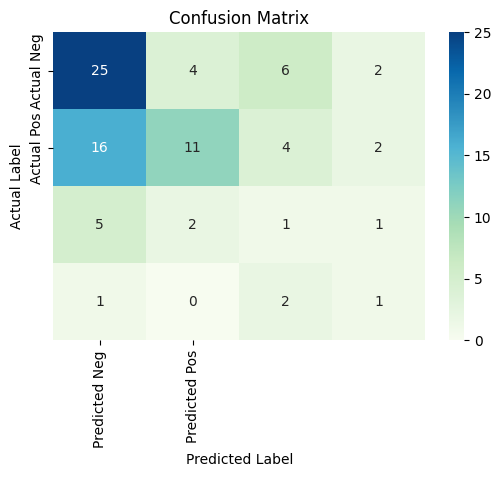

In [46]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nb = GaussianNB()
nb.fit(x_train, y_train)
ypred = nb.predict(x_test)

import seaborn as sns

# ১. Accuracy Score প্রিন্ট করা
accuracy = accuracy_score(y_test, ypred)
print(f"🎯 Accuracy Score: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("-" * 60)

# ২. Classification Report-কে সুন্দর টেবিলে রূপান্তর
print("📊 Classification Report:")
report_dict = classification_report(y_test, ypred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
# Colab-এ display() ব্যবহার করলে টেবিলটি দেখতে চমৎকার লাগে
display(report_df.round(2))
print("-" * 60)

# ৩. Confusion Matrix-কে সুন্দর কালারফুল হিটম্যাপে রূপান্তর
print("🧩 Confusion Matrix Heatmap:")
cm = confusion_matrix(y_test, ypred)

plt.figure(figsize=(6, 4))
# annot=True দিলে ঘরের ভেতর সংখ্যা দেখাবে, cmap দিয়ে কালার পরিবর্তন করা যায়
sns.heatmap(cm, annot=True, fmt='d', cmap='GnBu',
            xticklabels=['Predicted Neg', 'Predicted Pos'],
            yticklabels=['Actual Neg', 'Actual Pos'])

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

## 7️⃣ Gradient Boosting Classifier

### 🧠 বিস্তারিত থিওরি

**Gradient Boosting** হলো **Boosting** পরিবারের Algorithm — এটা ধাপে ধাপে দুর্বল মডেল তৈরি করে, প্রতিটি নতুন মডেল আগের মডেলের **ভুল (Error) ঠিক করার** চেষ্টা করে।

**সহজ উদাহরণ:**
একজন ছাত্র পরীক্ষা দিল, ভুল হলো। পরের বার শুধু ভুলগুলো নিয়ে পড়ল। আবার দিল, আবার ভুল হলো — আবার সেই ভুল নিয়ে পড়ল। এভাবে বারবার ভুল শুধরাতে শুধরাতে সে Expert হয়ে যায়।

### কীভাবে কাজ করে?

1. প্রথমে একটি সাধারণ Model তৈরি করো
2. সেই Model-এর **Error (Residual)** বের করো
3. পরের Model সেই Error-কে Predict করার চেষ্টা করে
4. এভাবে `n_estimators` সংখ্যক বার চলতে থাকে
5. সব Model-এর Output যোগ করে Final Prediction

$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$

যেখানে $\eta$ = Learning Rate, $h_m$ = নতুন Tree

### সুবিধা:
- সাধারণত সব Algorithm-এর মধ্যে **সবচেয়ে বেশি Accurate**
- Overfitting তুলনামূলক কম

### সমস্যা:
- **ধীর** — Sequential (একের পর এক) প্রক্রিয়া, Parallel করা যায় না
- Hyperparameter Tuning জরুরি (`n_estimators`, `learning_rate`, `max_depth`)

> ⚠️ **সাধারণ ভুল:** `learning_rate` বেশি দিলে Overfitting, কম দিলে অনেক `n_estimators` লাগে — দুটো Balance করতে হয়।

🎯 Accuracy Score: 0.5422 (54.22%)
------------------------------------------------------------
📊 Classification Report:


,precision,recall,f1-score,support
Environment,0.56,0.73,0.64,37.00
Family care,0.68,0.45,0.55,33.00
Physical well-being,0.12,0.11,0.12,9.00
Quantity of intake food,0.40,0.50,0.44,4.00
accuracy,0.54,0.54,0.54,0.54
macro avg,0.44,0.45,0.44,83.00
weighted avg,0.55,0.54,0.53,83.00


------------------------------------------------------------
🧩 Confusion Matrix Heatmap:


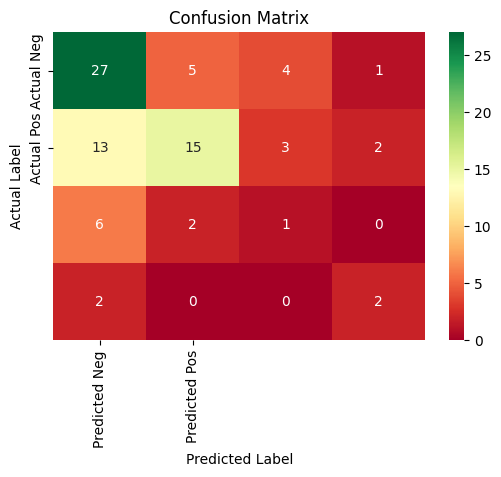

In [47]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

gb = GradientBoostingClassifier()
gb.fit(x_train, y_train)
ypred = gb.predict(x_test)

import seaborn as sns

# ১. Accuracy Score প্রিন্ট করা
accuracy = accuracy_score(y_test, ypred)
print(f"🎯 Accuracy Score: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("-" * 60)

# ২. Classification Report-কে সুন্দর টেবিলে রূপান্তর
print("📊 Classification Report:")
report_dict = classification_report(y_test, ypred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
# Colab-এ display() ব্যবহার করলে টেবিলটি দেখতে চমৎকার লাগে
display(report_df.round(2))
print("-" * 60)

# ৩. Confusion Matrix-কে সুন্দর কালারফুল হিটম্যাপে রূপান্তর
print("🧩 Confusion Matrix Heatmap:")
cm = confusion_matrix(y_test, ypred)

plt.figure(figsize=(6, 4))
# annot=True দিলে ঘরের ভেতর সংখ্যা দেখাবে, cmap দিয়ে কালার পরিবর্তন করা যায়
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Predicted Neg', 'Predicted Pos'],
            yticklabels=['Actual Neg', 'Actual Pos'])

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

## 8️⃣ AdaBoost Classifier

### 🧠 বিস্তারিত থিওরি

**AdaBoost (Adaptive Boosting)** — এটাও Boosting পরিবারের, কিন্তু Gradient Boosting থেকে একটু আলাদা।

**সহজ উদাহরণ:**
ক্লাসে দুর্বল ছাত্রদের বেশি মনোযোগ দেওয়া হয়। AdaBoost প্রতিটি Round-এ যে Data Point-গুলো ভুল হয়েছে, সেগুলোকে **বেশি Weight** দেয় — পরের Model সেগুলো ঠিক করার বেশি চেষ্টা করে।

### Gradient Boosting vs AdaBoost পার্থক্য:

| | AdaBoost | Gradient Boosting |
|---|---|---|
| কী Adjust করে? | Data-র **Weight** | আগের মডেলের **Error** |
| Base Learner | সাধারণত Stump (1-level Tree) | Decision Tree |
| গতি | দ্রুত | ধীর |
| Outlier Sensitivity | বেশি Sensitive | কম |

### সুবিধা:
- Implementation সহজ
- Overfitting তুলনামূলক কম (অনেক Base Learner ব্যবহার করলেও)

### সমস্যা:
- **Outlier-এর প্রতি Sensitive** — একটি Outlier বারবার বেশি Weight পেয়ে পুরো Model নষ্ট করতে পারে
- Noisy Data-তে ভালো কাজ করে না

> ⚠️ **সাধারণ ভুল:** Noisy বা Outlier-ভরা Dataset-এ AdaBoost ব্যবহার না করাই ভালো — Gradient Boosting বেছে নাও।

🎯 Accuracy Score: 0.3976 (39.76%)
------------------------------------------------------------
📊 Classification Report:


,precision,recall,f1-score,support
Environment,0.48,0.68,0.56,37.0
Family care,0.36,0.24,0.29,33.0
Physical well-being,0.00,0.00,0.00,9.0
Quantity of intake food,0.00,0.00,0.00,4.0
accuracy,0.40,0.40,0.40,0.4
macro avg,0.21,0.23,0.21,83.0
weighted avg,0.36,0.40,0.37,83.0


------------------------------------------------------------
🧩 Confusion Matrix Heatmap:


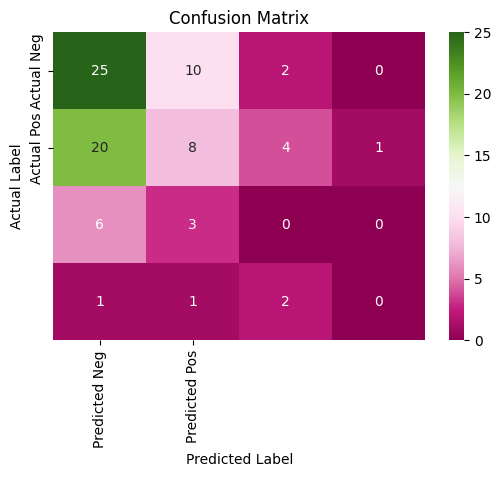

In [48]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

ada = AdaBoostClassifier()
ada.fit(x_train, y_train)
ypred = ada.predict(x_test)

import seaborn as sns

# ১. Accuracy Score প্রিন্ট করা
accuracy = accuracy_score(y_test, ypred)
print(f"🎯 Accuracy Score: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("-" * 60)

# ২. Classification Report-কে সুন্দর টেবিলে রূপান্তর
print("📊 Classification Report:")
report_dict = classification_report(y_test, ypred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
# Colab-এ display() ব্যবহার করলে টেবিলটি দেখতে চমৎকার লাগে
display(report_df.round(2))
print("-" * 60)

# ৩. Confusion Matrix-কে সুন্দর কালারফুল হিটম্যাপে রূপান্তর
print("🧩 Confusion Matrix Heatmap:")
cm = confusion_matrix(y_test, ypred)

plt.figure(figsize=(6, 4))
# annot=True দিলে ঘরের ভেতর সংখ্যা দেখাবে, cmap দিয়ে কালার পরিবর্তন করা যায়
sns.heatmap(cm, annot=True, fmt='d', cmap='PiYG',
            xticklabels=['Predicted Neg', 'Predicted Pos'],
            yticklabels=['Actual Neg', 'Actual Pos'])

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

## 9️⃣ Extra Trees Classifier

### 🧠 বিস্তারিত থিওরি

**Extra Trees (Extremely Randomized Trees)** হলো Random Forest-এরই একটি উন্নত সংস্করণ — কিন্তু আরও বেশি Randomness যোগ করা।

### Random Forest vs Extra Trees পার্থক্য:

| | Random Forest | Extra Trees |
|---|---|---|
| Split বেছে নেওয়া | **সেরা Split** খোঁজে (Optimal) | **সম্পূর্ণ Random Split** নেয় |
| গতি | ধীর | **অনেক দ্রুত** |
| Variance | কম | আরও কম |
| Bias | কম | একটু বেশি |

**সহজ উদাহরণ:**
Random Forest বলে: "100টি সম্ভাব্য প্রশ্নের মধ্যে সেরা প্রশ্নটি খুঁজে বের করো।"
Extra Trees বলে: "যেকোনো একটি প্রশ্ন তুলে নাও — হিসাব করার দরকার নেই!"

এই Randomness আসলে **Overfitting কমায়** এবং Speed বাড়ায়।

### সুবিধা:
- Random Forest-এর চেয়ে **দ্রুত**
- Variance আরও কম → সাধারণত Generalize ভালো করে

### সমস্যা:
- Bias একটু বেশি থাকতে পারে
- সব Dataset-এ Random Forest-এর চেয়ে ভালো নাও হতে পারে

> ⚠️ **কখন Extra Trees বেছে নেবে?** Dataset বড় হলে এবং Speed Priority হলে Extra Trees ভালো। ছোট Dataset-এ Random Forest ভালো ফলাফল দিতে পারে।


🎯 Accuracy Score: 0.4940 (49.40%)
------------------------------------------------------------
📊 Classification Report:


,precision,recall,f1-score,support
Environment,0.51,0.73,0.60,37.00
Family care,0.61,0.42,0.50,33.00
Physical well-being,0.00,0.00,0.00,9.00
Quantity of intake food,0.00,0.00,0.00,4.00
accuracy,0.49,0.49,0.49,0.49
macro avg,0.28,0.29,0.28,83.00
weighted avg,0.47,0.49,0.47,83.00


------------------------------------------------------------
🧩 Confusion Matrix Heatmap:


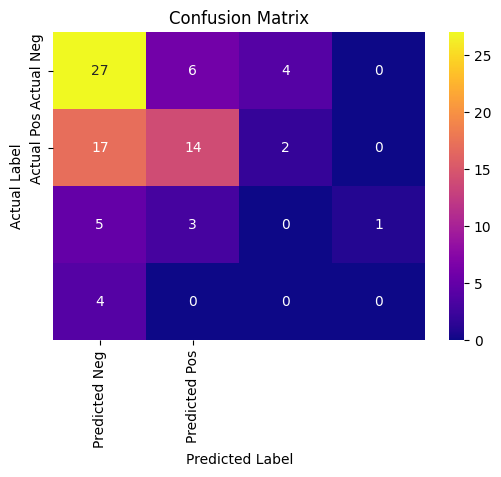

In [49]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

et = ExtraTreesClassifier()
et.fit(x_train, y_train)
ypred = et.predict(x_test)


import seaborn as sns

# ১. Accuracy Score প্রিন্ট করা
accuracy = accuracy_score(y_test, ypred)
print(f"🎯 Accuracy Score: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("-" * 60)

# ২. Classification Report-কে সুন্দর টেবিলে রূপান্তর
print("📊 Classification Report:")
report_dict = classification_report(y_test, ypred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
# Colab-এ display() ব্যবহার করলে টেবিলটি দেখতে চমৎকার লাগে
display(report_df.round(2))
print("-" * 60)

# ৩. Confusion Matrix-কে সুন্দর কালারফুল হিটম্যাপে রূপান্তর
print("🧩 Confusion Matrix Heatmap:")
cm = confusion_matrix(y_test, ypred)

plt.figure(figsize=(6, 4))
# annot=True দিলে ঘরের ভেতর সংখ্যা দেখাবে, cmap দিয়ে কালার পরিবর্তন করা যায়
sns.heatmap(cm, annot=True, fmt='d', cmap='plasma',
            xticklabels=['Predicted Neg', 'Predicted Pos'],
            yticklabels=['Actual Neg', 'Actual Pos'])

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

## 🔟 Bagging Classifier

### 🧠 বিস্তারিত থিওরি

**Bagging (Bootstrap Aggregating)** হলো একটি **Ensemble Method** — অনেকগুলো একই ধরনের মডেল আলাদাভাবে Train করে তাদের Result একসাথে Combine করা।

**সহজ উদাহরণ:**
একই পরীক্ষা ১০০ জনকে দাও, সবার উত্তর মিলিয়ে Majority নাও। যদিও সবাই একই বই পড়েছে, Random ভুলগুলো Cancel হয়ে যায়।

### কীভাবে কাজ করে?

1. Training Data থেকে **Bootstrap Sampling** — Random ভাবে (পুনরাবৃত্তি সহ) কিছু Sample নাও
2. প্রতিটি Sample দিয়ে আলাদা Model Train করো
3. Prediction-এ সব Model-এর **Majority Vote** নাও

$$\text{Bagging} = \frac{1}{n}\sum_{i=1}^{n} f_i(x)$$

### Random Forest vs Bagging পার্থক্য:

| | Bagging | Random Forest |
|---|---|---|
| Base Learner | যেকোনো Algorithm হতে পারে | শুধু Decision Tree |
| Feature Selection | সব Feature ব্যবহার করে | Random Feature Subset |
| Flexibility | বেশি | কম |

### সুবিধা:
- যেকোনো Base Algorithm (Decision Tree, KNN, etc.) দিয়ে কাজ করে
- Variance কমায়, Overfitting কমায়

### সমস্যা:
- Bias কমায় না
- Interpretability কমে (অনেক মডেল মিলে)

> ⚠️ **সাধারণ ভুল:** Default Base Estimator হলো Decision Tree। অন্য Algorithm ব্যবহার করতে চাইলে `estimator=` parameter দিতে হবে।

🎯 Accuracy Score: 0.5181 (51.81%)
------------------------------------------------------------
📊 Classification Report:


,precision,recall,f1-score,support
Environment,0.55,0.76,0.64,37.00
Family care,0.64,0.42,0.51,33.00
Physical well-being,0.12,0.11,0.12,9.00
Quantity of intake food,0.00,0.00,0.00,4.00
accuracy,0.52,0.52,0.52,0.52
macro avg,0.33,0.32,0.32,83.00
weighted avg,0.51,0.52,0.50,83.00


------------------------------------------------------------
🧩 Confusion Matrix Heatmap:


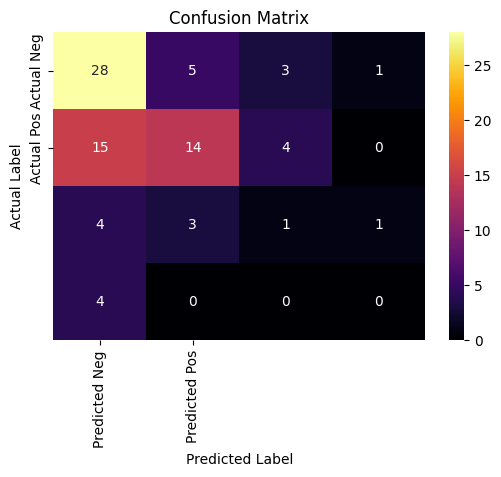

In [50]:
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

bag = BaggingClassifier()
bag.fit(x_train, y_train)
ypred = bag.predict(x_test)


import seaborn as sns

# ১. Accuracy Score প্রিন্ট করা
accuracy = accuracy_score(y_test, ypred)
print(f"🎯 Accuracy Score: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("-" * 60)

# ২. Classification Report-কে সুন্দর টেবিলে রূপান্তর
print("📊 Classification Report:")
report_dict = classification_report(y_test, ypred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
# Colab-এ display() ব্যবহার করলে টেবিলটি দেখতে চমৎকার লাগে
display(report_df.round(2))
print("-" * 60)

# ৩. Confusion Matrix-কে সুন্দর কালারফুল হিটম্যাপে রূপান্তর
print("🧩 Confusion Matrix Heatmap:")
cm = confusion_matrix(y_test, ypred)

plt.figure(figsize=(6, 4))
# annot=True দিলে ঘরের ভেতর সংখ্যা দেখাবে, cmap দিয়ে কালার পরিবর্তন করা যায়
sns.heatmap(cm, annot=True, fmt='d', cmap='inferno',
            xticklabels=['Predicted Neg', 'Predicted Pos'],
            yticklabels=['Actual Neg', 'Actual Pos'])

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

## 1️⃣1️⃣ Linear Discriminant Analysis (LDA)

### 🧠 বিস্তারিত থিওরি

**LDA** একটি Statistical Algorithm যা **Class গুলোর মধ্যে সবচেয়ে বড় পার্থক্য** তৈরি করে এমন একটি নতুন Axis (Direction) খোঁজে — যাতে আলাদা Class গুলো যতটা সম্ভব দূরে থাকে এবং একই Class-এর Points কাছে থাকে।

**সহজ উদাহরণ:**
কল্পনা করো দুটি গ্রুপের মানুষ একটি মাঠে দাঁড়িয়ে আছে। LDA এমন একটি রেখা খোঁজে যার উপর Shadow ফেললে দুটি গ্রুপ সবচেয়ে বেশি আলাদা হয়।

### দুটি লক্ষ্য LDA-র:

$$\text{Maximize: } \frac{\text{Between-Class Variance}}{\text{Within-Class Variance}}$$

মানে: ভিন্ন Class-এর মধ্যে দূরত্ব বাড়াও, একই Class-এর মধ্যে দূরত্ব কমাও।

### সুবিধা:
- **Dimensionality Reduction** — অনেক Feature কে কম Feature-এ নিয়ে আসে
- Class separation সর্বোচ্চ করে
- দ্রুত এবং মেমোরি-বান্ধব

### সমস্যা:
- Data **Normally Distributed** ধরে নেয় — বাস্তবে সবসময় সত্য না
- Classes-এর মধ্যে Linear Boundary ধরে নেয়
- Normalization দরকার

> ⚠️ **LDA vs PCA পার্থক্য:** PCA শুধু Variance সর্বোচ্চ করে (Unsupervised), LDA Class Separation সর্বোচ্চ করে (Supervised)।

🎯 Accuracy Score: 0.5301 (53.01%)
------------------------------------------------------------
📊 Classification Report:


,precision,recall,f1-score,support
Environment,0.55,0.76,0.64,37.00
Family care,0.74,0.42,0.54,33.00
Physical well-being,0.20,0.22,0.21,9.00
Quantity of intake food,0.00,0.00,0.00,4.00
accuracy,0.53,0.53,0.53,0.53
macro avg,0.37,0.35,0.35,83.00
weighted avg,0.56,0.53,0.52,83.00


------------------------------------------------------------
🧩 Confusion Matrix Heatmap:


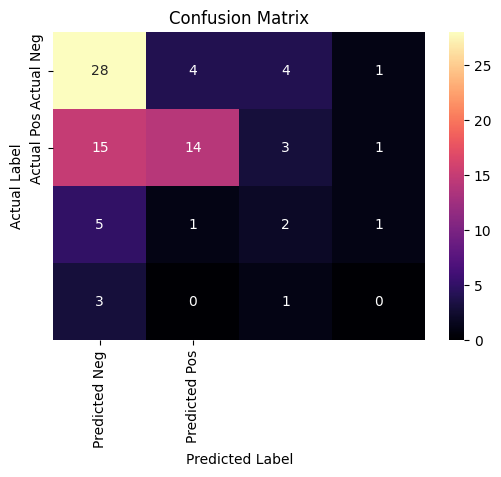

In [51]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lda = LinearDiscriminantAnalysis()
lda.fit(x_train, y_train)
ypred = lda.predict(x_test)


import seaborn as sns

# ১. Accuracy Score প্রিন্ট করা
accuracy = accuracy_score(y_test, ypred)
print(f"🎯 Accuracy Score: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("-" * 60)

# ২. Classification Report-কে সুন্দর টেবিলে রূপান্তর
print("📊 Classification Report:")
report_dict = classification_report(y_test, ypred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
# Colab-এ display() ব্যবহার করলে টেবিলটি দেখতে চমৎকার লাগে
display(report_df.round(2))
print("-" * 60)

# ৩. Confusion Matrix-কে সুন্দর কালারফুল হিটম্যাপে রূপান্তর
print("🧩 Confusion Matrix Heatmap:")
cm = confusion_matrix(y_test, ypred)

plt.figure(figsize=(6, 4))
# annot=True দিলে ঘরের ভেতর সংখ্যা দেখাবে, cmap দিয়ে কালার পরিবর্তন করা যায়
sns.heatmap(cm, annot=True, fmt='d', cmap='magma',
            xticklabels=['Predicted Neg', 'Predicted Pos'],
            yticklabels=['Actual Neg', 'Actual Pos'])

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

## 1️⃣2️⃣ Ridge Classifier

### 🧠 বিস্তারিত থিওরি

**Ridge Classifier** হলো **Ridge Regression** এর Classification সংস্করণ। এটি Linear Model — কিন্তু **Regularization (L2 Penalty)** যোগ করে Overfitting কমায়।

### Regularization কী? — একদম সহজে

সাধারণ Linear Model শেখার সময় যেকোনো Coefficient ($m$) বড় হতে পারে — এতে Overfitting হয়।
Ridge বলে: "Coefficient বড় হলে Extra Penalty দেব।"

$$\text{Cost} = \text{MSE} + \alpha \sum_{i=1}^{n} \beta_i^2$$

- $\alpha$ = Regularization Strength (বড় হলে Coefficient ছোট হয়)
- $\beta_i$ = Model-এর Coefficients

### কীভাবে Classification করে?

Ridge Regression যে Continuous Output দেয়, তাকে **Threshold** দিয়ে Class-এ ভাগ করা হয়।

### সুবিধা:
- **দ্রুত** — বড় Dataset-এ ভালো কাজ করে
- Multicollinearity (Features-এর মধ্যে Correlation) Handle করে ভালো
- Overfitting কম

### সমস্যা:
- Linear Boundary — Non-linear Data-তে কাজ করে না
- `alpha` সঠিকভাবে বেছে নেওয়া জরুরি

> ⚠️ **Ridge vs Lasso পার্থক্য:** Ridge (L2) কখনো Coefficient একদম 0 করে না, Lasso (L1) করতে পারে (Feature Selection)।

🎯 Accuracy Score: 0.5422 (54.22%)
------------------------------------------------------------
📊 Classification Report:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,precision,recall,f1-score,support
Environment,0.55,0.78,0.64,37.00
Family care,0.65,0.45,0.54,33.00
Physical well-being,0.14,0.11,0.12,9.00
Quantity of intake food,0.00,0.00,0.00,4.00
accuracy,0.54,0.54,0.54,0.54
macro avg,0.34,0.34,0.33,83.00
weighted avg,0.52,0.54,0.51,83.00


------------------------------------------------------------
🧩 Confusion Matrix Heatmap:


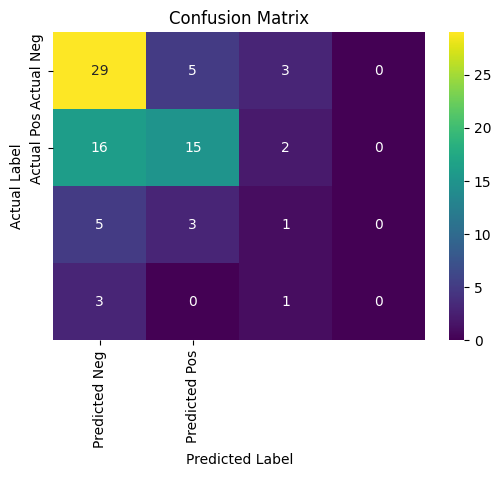

In [52]:
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

ridge = RidgeClassifier()
ridge.fit(x_train, y_train)
ypred = ridge.predict(x_test)


import seaborn as sns

# ১. Accuracy Score প্রিন্ট করা
accuracy = accuracy_score(y_test, ypred)
print(f"🎯 Accuracy Score: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("-" * 60)

# ২. Classification Report-কে সুন্দর টেবিলে রূপান্তর
print("📊 Classification Report:")
report_dict = classification_report(y_test, ypred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
# Colab-এ display() ব্যবহার করলে টেবিলটি দেখতে চমৎকার লাগে
display(report_df.round(2))
print("-" * 60)

# ৩. Confusion Matrix-কে সুন্দর কালারফুল হিটম্যাপে রূপান্তর
print("🧩 Confusion Matrix Heatmap:")
cm = confusion_matrix(y_test, ypred)

plt.figure(figsize=(6, 4))
# annot=True দিলে ঘরের ভেতর সংখ্যা দেখাবে, cmap দিয়ে কালার পরিবর্তন করা যায়
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            xticklabels=['Predicted Neg', 'Predicted Pos'],
            yticklabels=['Actual Neg', 'Actual Pos'])

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

## 1️⃣3️⃣ SGD Classifier (Stochastic Gradient Descent)

### 🧠 বিস্তারিত থিওরি

**SGD Classifier** হলো **Gradient Descent** Optimization ব্যবহার করে যেকোনো Linear Model Train করার একটি দ্রুত পদ্ধতি।

### Gradient Descent কী? — একদম সহজে

কল্পনা করো তুমি পাহাড়ের উপরে আছ, চোখ বন্ধ করে সবচেয়ে নিচু জায়গায় (Valley/Minimum) নামতে চাও। প্রতি পদক্ষেপে যেদিকে ঢাল (Gradient) নিচের দিকে, সেদিকে যাও।

| ধরন | প্রতিটি পদক্ষেপে কতটুকু Data দেখে | গতি |
|---|---|---|
| Batch Gradient Descent | পুরো Dataset | ধীর কিন্তু Stable |
| **Stochastic (SGD)** | **একটি মাত্র Sample** | দ্রুত কিন্তু Noisy |
| Mini-Batch | ছোট Batch | Balance |

### কেন SGD দ্রুত?

পুরো Dataset-এর Gradient বের না করে **একটি Random Sample** দেখেই Parameter Update করে — তাই বড় Dataset-এ অনেক দ্রুত।

### সুবিধা:
- **বিশাল Dataset-এর জন্য আদর্শ** (Millions of Rows)
- মেমোরি কম লাগে
- Online Learning (নতুন Data আসলে Update করা) সম্ভব

### সমস্যা:
- **Noisy** — প্রতিটি Update-এ উঠানামা করে, Convergence কঠিন
- Learning Rate Tuning জরুরি
- Normalization **অবশ্যই** দরকার

> ⚠️ **সাধারণ ভুল:** SGD-তে `random_state` না দিলে প্রতিবার ভিন্ন ফলাফল আসে। এছাড়া Normalization ছাড়া SGD প্রায়ই ঠিকমতো Converge করে না।

🎯 Accuracy Score: 0.3494 (34.94%)
------------------------------------------------------------
📊 Classification Report:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,precision,recall,f1-score,support
Environment,0.64,0.19,0.29,37.00
Family care,0.59,0.48,0.53,33.00
Physical well-being,0.13,0.67,0.22,9.00
Quantity of intake food,0.00,0.00,0.00,4.00
accuracy,0.35,0.35,0.35,0.35
macro avg,0.34,0.34,0.26,83.00
weighted avg,0.53,0.35,0.37,83.00


------------------------------------------------------------
🧩 Confusion Matrix Heatmap:


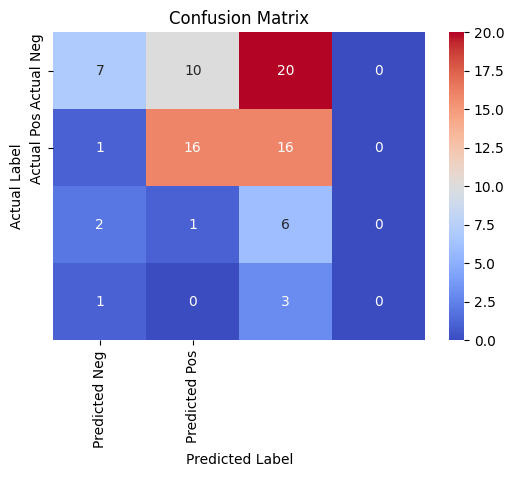

In [53]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sgd = SGDClassifier()
sgd.fit(x_train, y_train)
ypred = sgd.predict(x_test)


import seaborn as sns

# ১. Accuracy Score প্রিন্ট করা
accuracy = accuracy_score(y_test, ypred)
print(f"🎯 Accuracy Score: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("-" * 60)

# ২. Classification Report-কে সুন্দর টেবিলে রূপান্তর
print("📊 Classification Report:")
report_dict = classification_report(y_test, ypred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
# Colab-এ display() ব্যবহার করলে টেবিলটি দেখতে চমৎকার লাগে
display(report_df.round(2))
print("-" * 60)

# ৩. Confusion Matrix-কে সুন্দর কালারফুল হিটম্যাপে রূপান্তর
print("🧩 Confusion Matrix Heatmap:")
cm = confusion_matrix(y_test, ypred)

plt.figure(figsize=(6, 4))
# annot=True দিলে ঘরের ভেতর সংখ্যা দেখাবে, cmap দিয়ে কালার পরিবর্তন করা যায়
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=['Predicted Neg', 'Predicted Pos'],
            yticklabels=['Actual Neg', 'Actual Pos'])

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

## 🏆 সব Model-এর Accuracy তুলনা — Best Model বেছে নেওয়া

**Accuracy jeita beshi sei model/algorithm ta nibo. Erpr erokom aro lazy model algorithm apply apply korbe supervised and unsupervised algorithm** ✅

এখানে সব ১৩টি Model-এর Accuracy একসাথে Sorted আকারে দেখানো হচ্ছে — **সবচেয়ে বেশি Accuracy যে মডেলের, সেটাই আমাদের Final Best Model।**

### কেন সব Algorithm চালালাম?

কোন Dataset-এ কোন Algorithm সবচেয়ে ভালো কাজ করবে — সেটা আগে থেকে বলা সম্ভব নয়। তাই **সব Algorithm চালিয়ে Compare করাই** সবচেয়ে বুদ্ধিমানের কাজ। এই পদ্ধতিকে বলে **"Lazy Evaluation"** বা **"Algorithm Comparison"**।

> 💡 Real-world ML Project-এ এই ধাপকে বলে **Model Selection** — বিভিন্ন Algorithm চালিয়ে সেরাটি বেছে পরে **Hyperparameter Tuning** করা হয়।

---

# 🏁 চূড়ান্ত সারসংক্ষেপ (Final Summary)

| Algorithm | ধরন | Normalization লাগে? | কখন ভালো |
|---|---|---|---|
| **Decision Tree** | Tree | না | সহজ, Interpretable ডেটা |
| **KNN** | Distance | ✅ হ্যাঁ | ছোট Dataset |
| **Random Forest** | Ensemble (Bagging) | না | সাধারণ সব ক্ষেত্রে |
| **Logistic Regression** | Linear | ✅ হ্যাঁ | Binary/Linear সমস্যা |
| **SVM** | Margin-based | ✅ হ্যাঁ | High Dimensional |
| **Naive Bayes** | Probabilistic | না | Text, Fast দরকার হলে |
| **Gradient Boosting** | Ensemble (Boosting) | না | সর্বোচ্চ Accuracy দরকার |
| **AdaBoost** | Ensemble (Boosting) | না | Clean Data |
| **Extra Trees** | Ensemble (Bagging) | না | Speed দরকার |
| **Bagging** | Ensemble (Bagging) | না | Variance কমাতে |
| **LDA** | Statistical | ✅ হ্যাঁ | Normal Distribution Data |
| **Ridge** | Linear + Regularization | ✅ হ্যাঁ | Multicollinearity |
| **SGD** | Optimization | ✅ হ্যাঁ | বিশাল Dataset |

> ⭐ যদি এই নোটবুকটি ভালো লাগে, GitHub-এ Star দিতে ভুলো না!